<a href="https://colab.research.google.com/github/Arijitde24/Machine-learning/blob/main/ML%20Projects/Multicolinearity_and_VIF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/DATASETS/bank-additional-full_final (3).csv')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [ ]:
df.shape

(41188, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
# data<30% data null ----> DROP
# data>30% data null ----> FILL NULL (category ==> mode, numerical ==> mean)

In [ ]:
df.duplicated().sum()

np.int64(1784)

In [ ]:
df.drop_duplicates(keep='first',inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

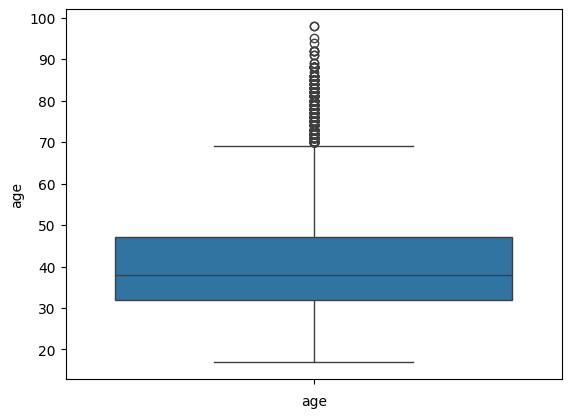

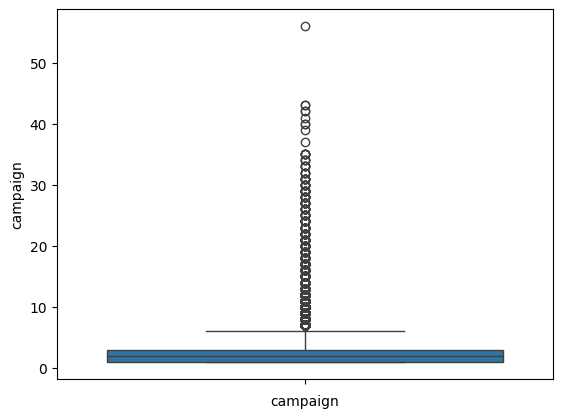

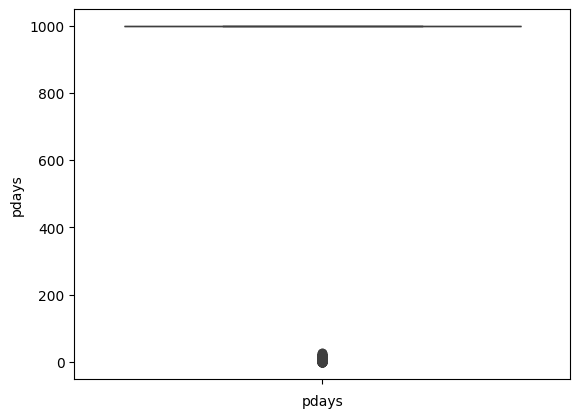

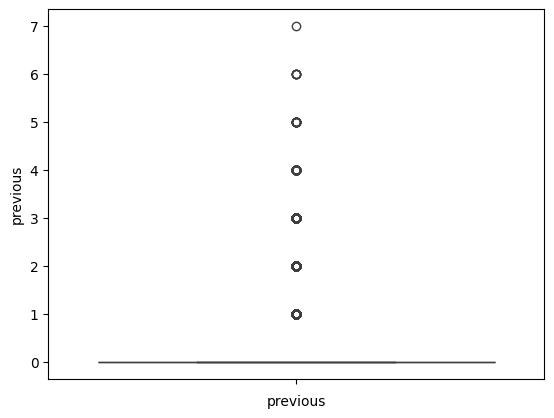

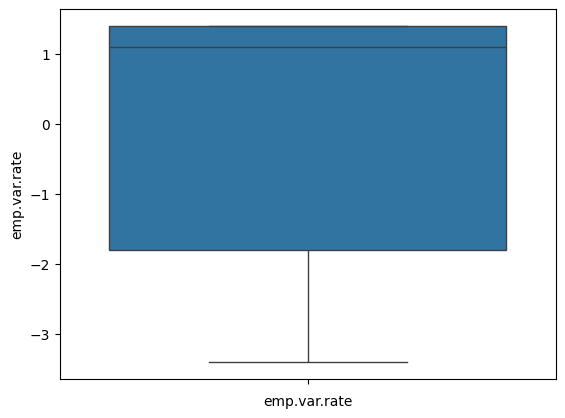

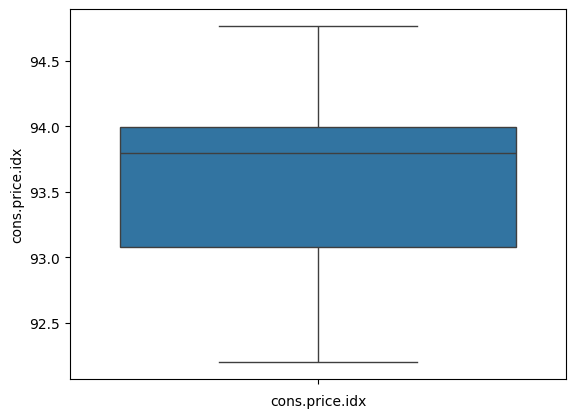

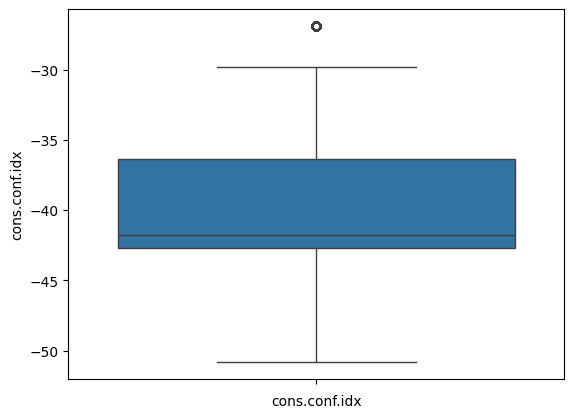

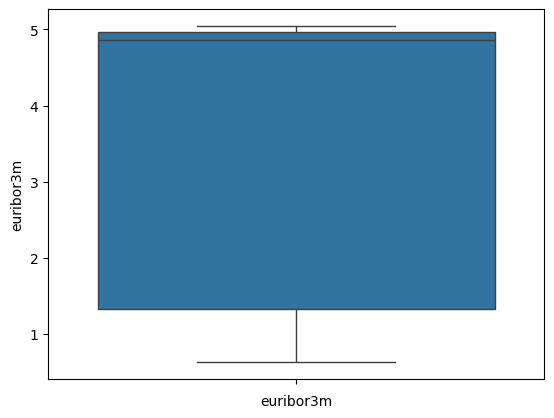

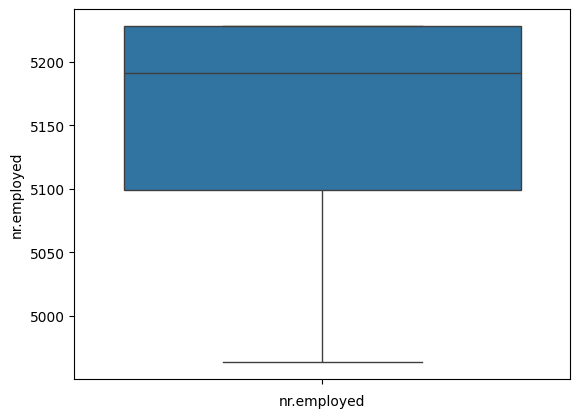

In [ ]:
for col in df.columns:
  if df[col].dtype != 'object':
    sns.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [ ]:
out_col=['age','campaign','cons.conf.idx']
for col in out_col:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1
  lower_limit= Q1 - 1.5 * IQR
  upper_limit= Q3 + 1.5 * IQR
  df=df[(df[col]<=upper_limit)&(df[col]>=lower_limit)]
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41181,37,admin.,married,university.degree,no,yes,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41182,29,unemployed,single,basic.4y,no,yes,no,cellular,nov,fri,1,9,1,success,-1.1,94.767,-50.8,1.028,4963.6,no
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no


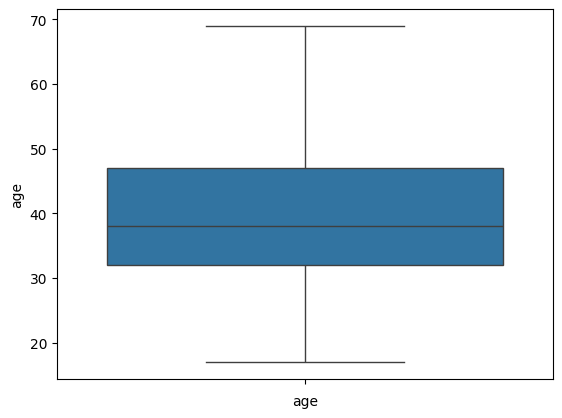

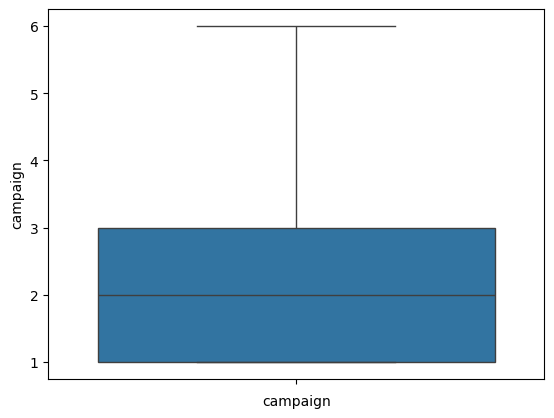

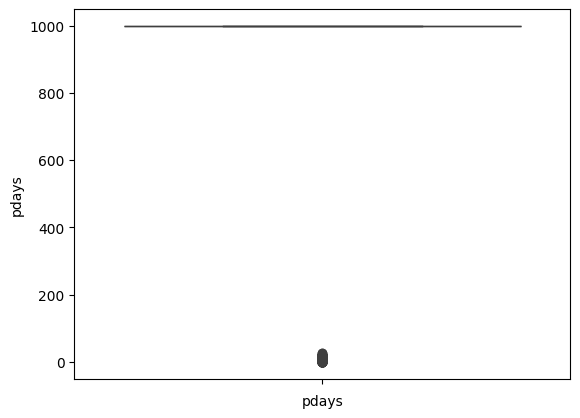

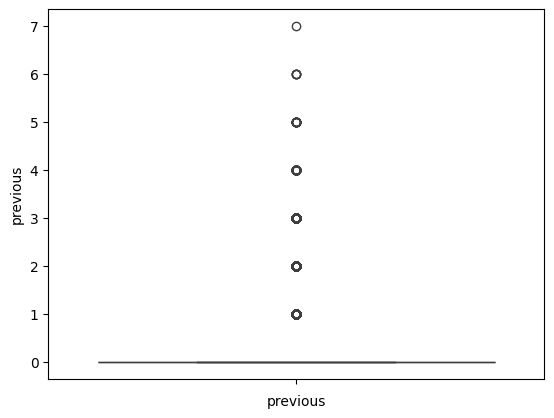

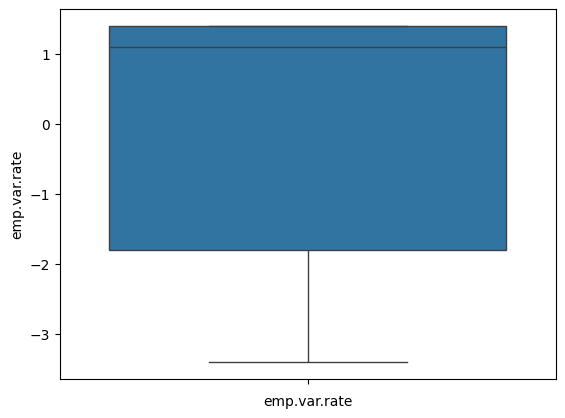

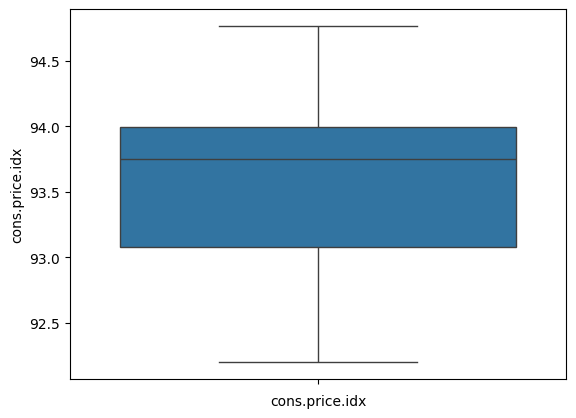

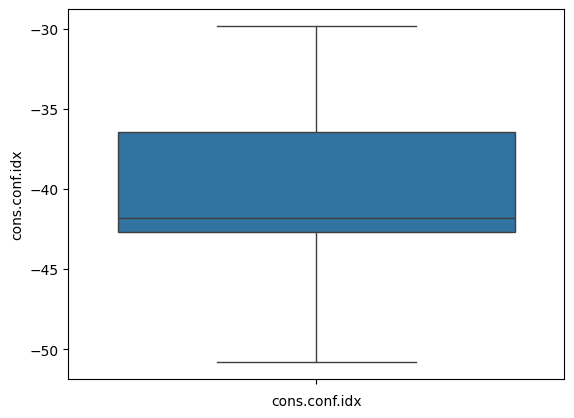

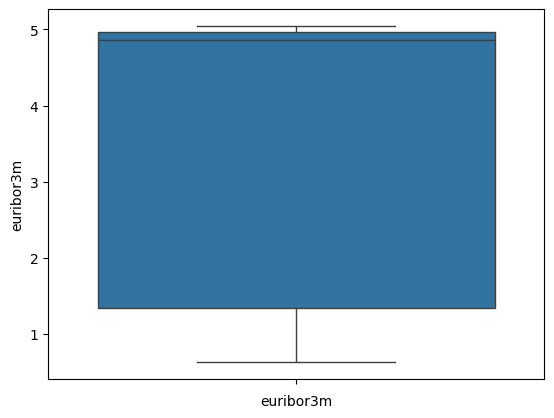

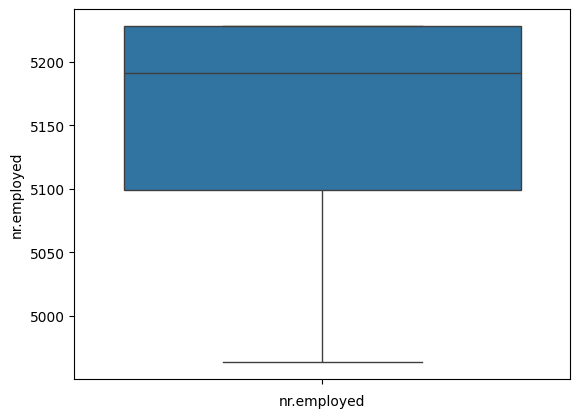

In [ ]:
for col in df.columns:
  if df[col].dtype != 'object':
    sns.boxplot(df[col])
    plt.xlabel(col)
    plt.show()


In [ ]:
le = LabelEncoder()
mapping = {}

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])
        mapping[col] = dict(zip(le.classes_, le.transform(le.classes_)))  # Store per-column mapping

# Print the full mapping for each column
for col, value in mapping.items():
    print(f"Column: {col}")
    for k, v in value.items():
        print(f"  {k} ===> {v}")


Column: job
  admin. ===> 0
  blue-collar ===> 1
  entrepreneur ===> 2
  housemaid ===> 3
  management ===> 4
  retired ===> 5
  self-employed ===> 6
  services ===> 7
  student ===> 8
  technician ===> 9
  unemployed ===> 10
  unknown ===> 11
Column: marital
  divorced ===> 0
  married ===> 1
  single ===> 2
  unknown ===> 3
Column: education
  basic.4y ===> 0
  basic.6y ===> 1
  basic.9y ===> 2
  high.school ===> 3
  illiterate ===> 4
  professional.course ===> 5
  university.degree ===> 6
  unknown ===> 7
Column: default
  no ===> 0
  unknown ===> 1
  yes ===> 2
Column: housing
  no ===> 0
  unknown ===> 1
  yes ===> 2
Column: loan
  no ===> 0
  unknown ===> 1
  yes ===> 2
Column: contact
  cellular ===> 0
  telephone ===> 1
Column: month
  apr ===> 0
  aug ===> 1
  dec ===> 2
  jul ===> 3
  jun ===> 4
  mar ===> 5
  may ===> 6
  nov ===> 7
  oct ===> 8
  sep ===> 9
Column: day_of_week
  fri ===> 0
  mon ===> 1
  thu ===> 2
  tue ===> 3
  wed ===> 4
Column: poutcome
  failure ===> 0

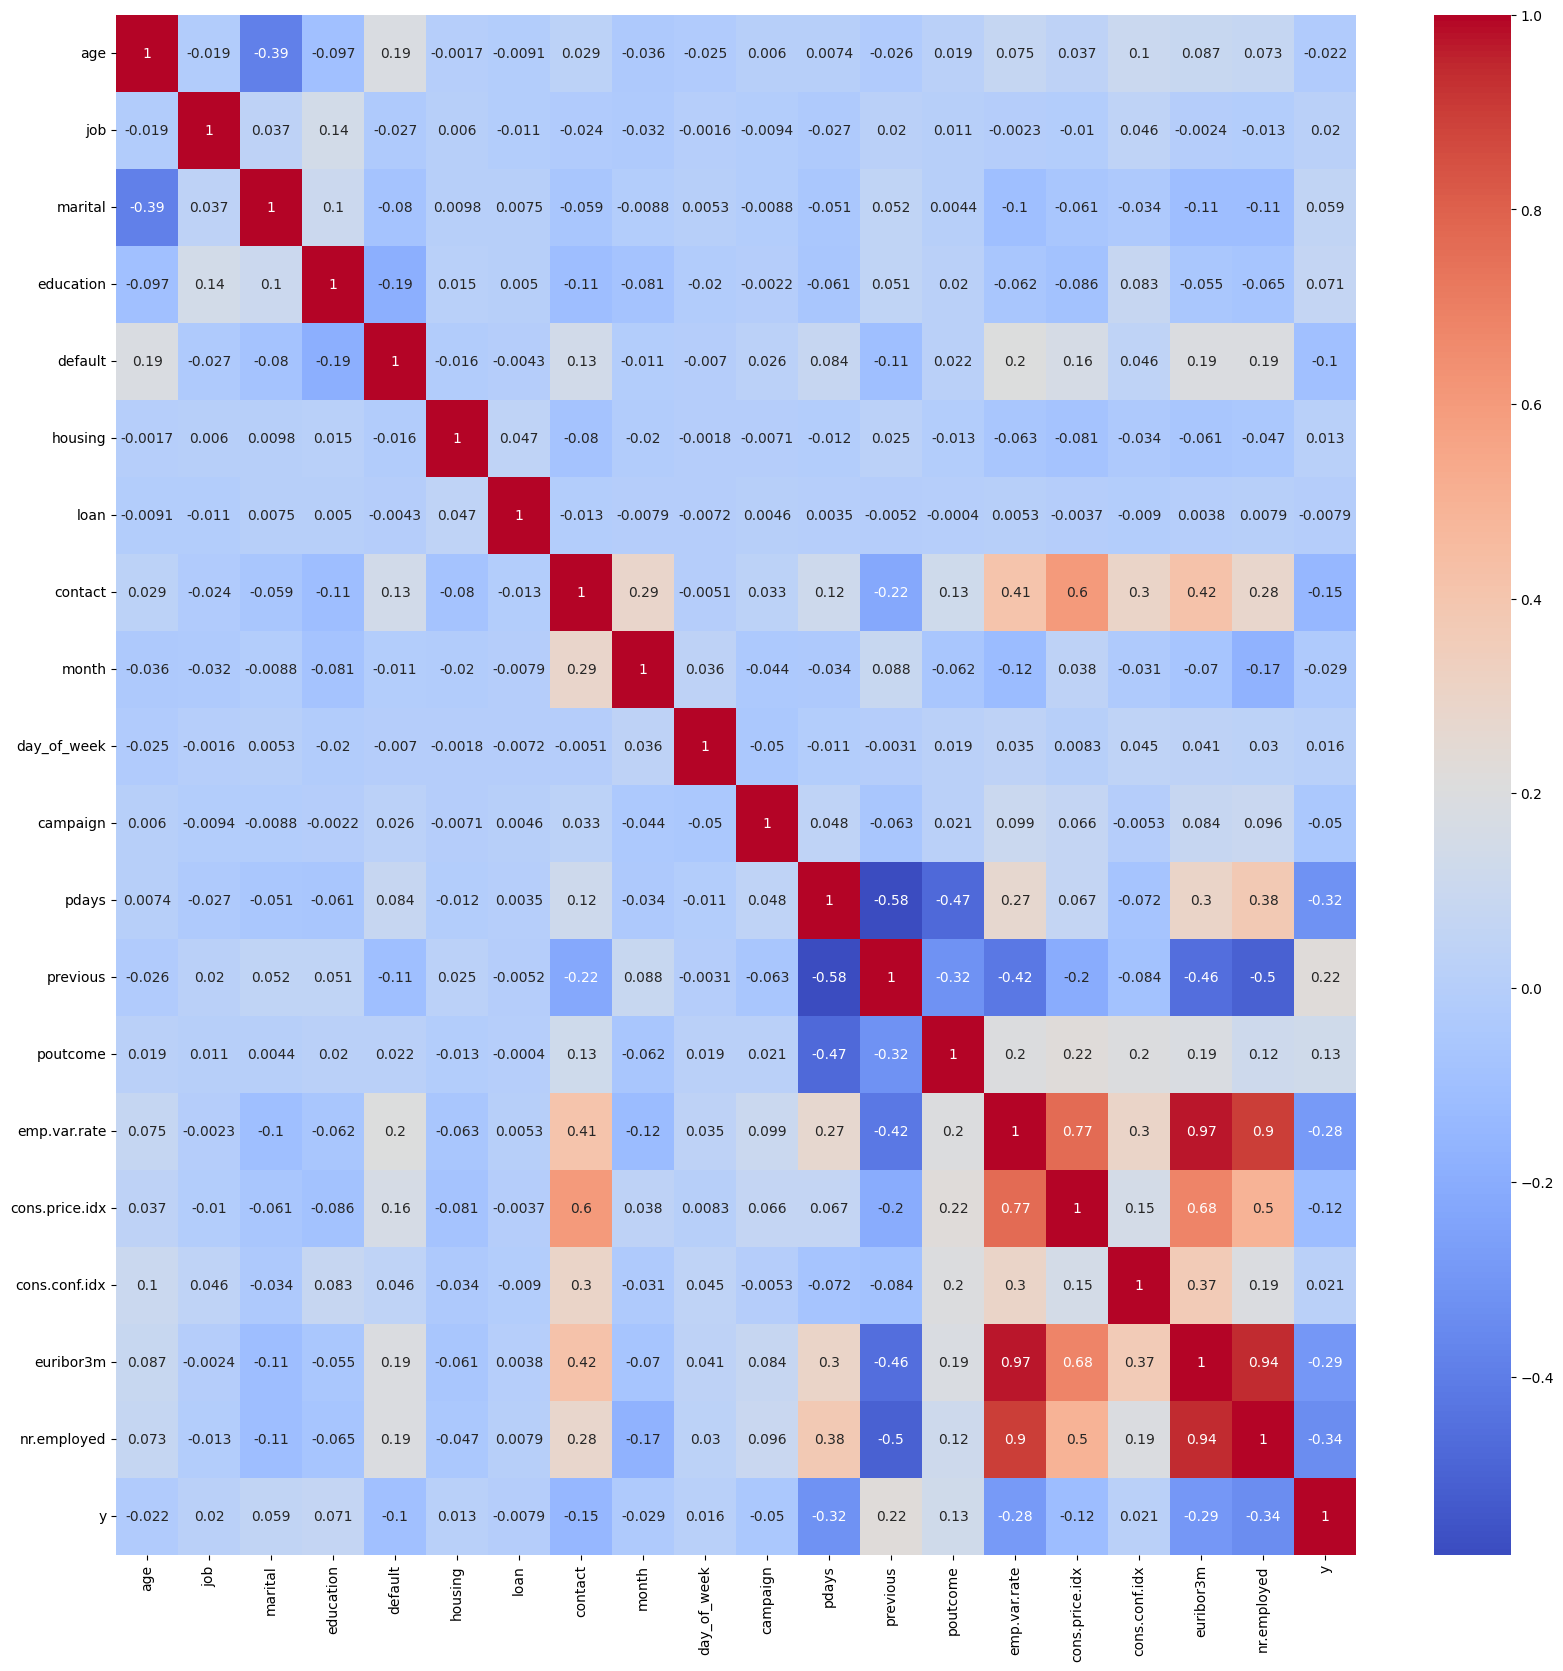

In [ ]:
plt.figure(figsize=(20, 20))
sns.heatmap(data=df.corr(), annot=True, cmap='coolwarm')
plt.show()

## VIF

It is a Multicollinearity Detection Method in Feature selection

Multicollinerity means that two or more independent feature are highly correalted with each other

It will quantify how much each feature is correlated with other features in a dataset.

1. x1,x2,x3 -- independent variables
2. y -- dependent variables

step 1) Regress x1 on all the other independent variables

3. y =mx + c , y = m1x1 + m2x2 + m3x3

x1 = m2x2 + m3x3 + c  --- 0.82

x2 = m1x1 + m3x3 + c

x3 = m1x1 + m2x2 + c

step 2 ) computer R2 value of the regression -- This will tell how other features are predicting x1 , x2 and x3

step 3 ) plug in the values of r2 in the vif formula

vif(x1) = 1/ (1-r2)

vif = 1 -- No mulitcolllinearity

vif = 1-5 Moderate accepatable

vif > 5 - high multicollinearity

In [ ]:
x=df.drop('y',axis=1)
y=df['y']

In [ ]:
x

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,3,1,0,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
1,57,7,1,3,1,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
2,37,7,1,3,0,2,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
3,40,0,1,1,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
4,56,7,1,3,0,0,2,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41181,37,0,1,6,0,2,0,0,7,0,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6
41182,29,10,2,0,0,2,0,0,7,0,1,9,1,2,-1.1,94.767,-50.8,1.028,4963.6
41184,46,1,1,5,0,0,0,0,7,0,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6
41185,56,5,1,6,0,2,0,0,7,0,2,999,0,1,-1.1,94.767,-50.8,1.028,4963.6


In [ ]:
y

,y
0,0
1,0
2,0
3,0
4,0
...,...
41181,1
41182,0
41184,0
41185,0


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
vif_df = pd.DataFrame()

In [ ]:
vif_df['Features'] = x.columns

In [ ]:
vif_df

,Features
0,age
1,job
2,marital
3,education
4,default
5,housing
6,loan
7,contact
8,month
9,day_of_week


In [ ]:
vif_df['Multicollinearity'] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
vif_df.sort_values('Multicollinearity', ascending=False,inplace=True)
vif_df

,Features,Multicollinearity
18,nr.employed,41995.189046
15,cons.price.idx,36695.731219
17,euribor3m,317.750890
11,pdays,164.628320
16,cons.conf.idx,143.302844
14,emp.var.rate,37.494545
13,poutcome,33.497216
0,age,21.966070
8,month,6.604837
12,previous,6.028235


In [ ]:
for i in range(len(x.columns)):
  vif = variance_inflation_factor(x.values,i)
  print(f'vif for {x.columns[i]} is {vif}')

vif for age is 21.966070454402285
vif for job is 2.1145506549496322
vif for marital is 5.649477190442339
vif for education is 4.533743331984292
vif for default is 1.413485603539284
vif for housing is 2.200633644198795
vif for loan is 1.2176088633103108
vif for contact is 2.935269716439509
vif for month is 6.604836798011397
vif for day_of_week is 3.0848606627114052
vif for campaign is 3.665084550934581
vif for pdays is 164.62831996241005
vif for previous is 6.028234902206734
vif for poutcome is 33.49721624624969
vif for emp.var.rate is 37.49454522440181
vif for cons.price.idx is 36695.73121886002
vif for cons.conf.idx is 143.30284378596946
vif for euribor3m is 317.7508900878543
vif for nr.employed is 41995.18904624725


In [ ]:
x.drop('nr.employed',axis = 1 , inplace = True)
x.drop('cons.price.idx',axis =1 , inplace = True)
x.drop('pdays',axis =1,inplace = True)
x.drop('euribor3m',axis =1 , inplace = True)
x.drop('cons.conf.idx',axis = 1 , inplace = True)
x.drop('age',axis =1 , inplace = True)
x.drop('poutcome',axis =1 , inplace = True)

In [ ]:
vif_df = pd.DataFrame()
vif_df['Features']=x.columns
vif_df['Multicollinearity'] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
vif_df.sort_values('Multicollinearity', ascending=False,inplace=True)
vif_df

,Features,Multicollinearity
7,month,4.390682
1,marital,4.034238
2,education,3.721585
9,campaign,3.071028
8,day_of_week,2.732719
6,contact,2.248569
4,housing,2.059338
0,job,2.042861
11,emp.var.rate,1.534253
10,previous,1.376780


In [ ]:
x

,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,emp.var.rate
0,3,1,0,0,0,0,1,6,1,1,0,1.1
1,7,1,3,1,0,0,1,6,1,1,0,1.1
2,7,1,3,0,2,0,1,6,1,1,0,1.1
3,0,1,1,0,0,0,1,6,1,1,0,1.1
4,7,1,3,0,0,2,1,6,1,1,0,1.1
...,...,...,...,...,...,...,...,...,...,...,...,...
41181,0,1,6,0,2,0,0,7,0,1,0,-1.1
41182,10,2,0,0,2,0,0,7,0,1,1,-1.1
41184,1,1,5,0,0,0,0,7,0,1,0,-1.1
41185,5,1,6,0,2,0,0,7,0,2,0,-1.1


In [ ]:
y

,y
0,0
1,0
2,0
3,0
4,0
...,...
41181,1
41182,0
41184,0
41185,0


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
lr=LogisticRegression()

In [ ]:
lr.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred=lr.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
accuracy_score(y_test,y_pred)*100

88.2808181315644

In [ ]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[6356,   24],
       [ 824,   32]])

In [ ]:
# True negative - 4883
# False positive - 63
# False Negative - 450
# True positive - 82

In [ ]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      6380
           1       0.57      0.04      0.07       856

    accuracy                           0.88      7236
   macro avg       0.73      0.52      0.50      7236
weighted avg       0.85      0.88      0.83      7236

